In [ ]:
import math
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy.typing import NDArray


# 1. Statistical analysis

We investigate the joint distributions of $(\omega,T)$ and $(A,E)$.

In [64]:
def load_results(
        dataset: str, method: str, hard_infix: str, fraction: str, level_infix: str) -> pd.DataFrame:
    """Load results given dataset, method type, and information about label type, fraction, level of analysis."""
    filename = f"{method}-{hard_infix}-{fraction}-{level_infix}.jsonl"
    results_path = Path("..") / "results" / dataset / filename
    if not results_path.exists():
        raise FileNotFoundError(results_path)

    return pd.read_json(results_path, lines=True)


def read_uncertainties(df: pd.DataFrame, level_infix: str) -> tuple[NDArray, NDArray]:
    """Extract aleatoric and epistemic uncertainty scores from dataframe."""
    if level_infix == "sampling":
        raise NotImplementedError

    all_au_flat = np.concatenate(df["all_au"].to_list())
    all_eu_flat = np.concatenate(df["all_mi"].to_list())
    return all_au_flat, all_eu_flat

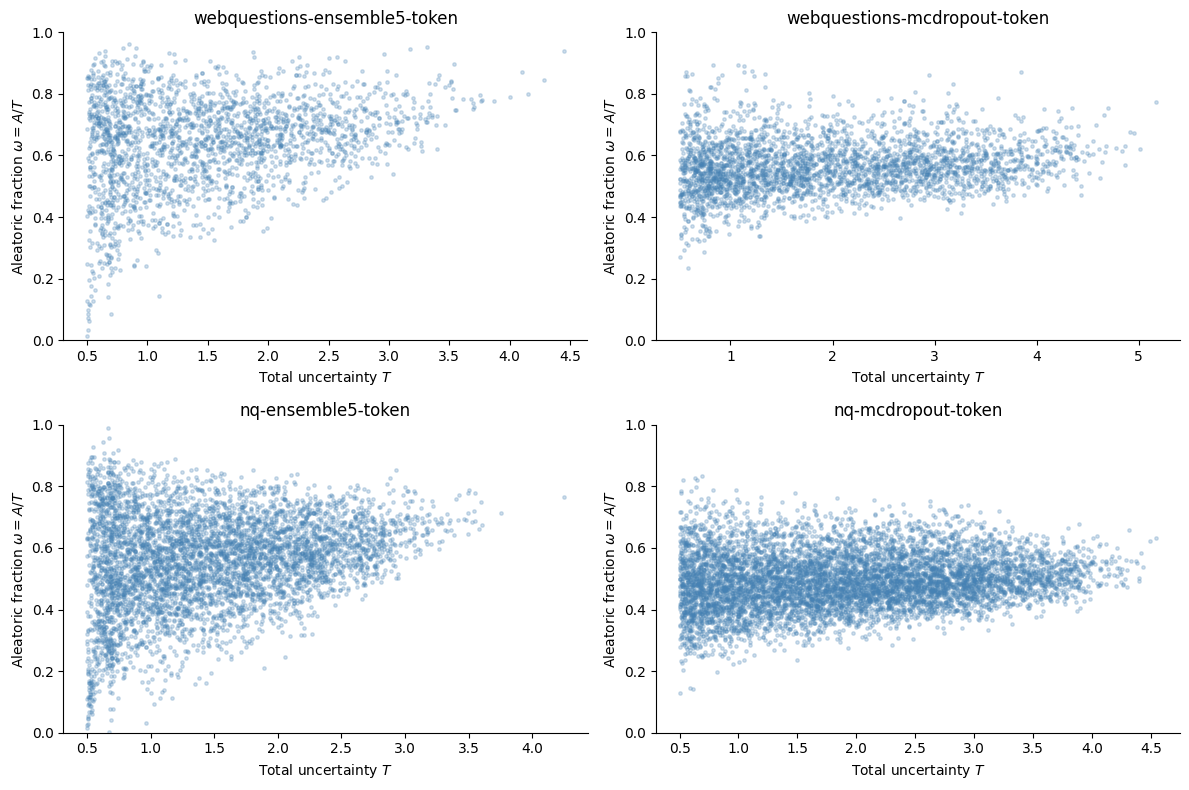

In [65]:
datasets = ("webquestions", "nq")
methods = ("ensemble5", "mcdropout")
level_infixes = ("token",)
eps = 0.5

combinations = list(product(datasets, methods, level_infixes))
n_plots = len(combinations)

cols = 2
rows = math.ceil(n_plots / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = axes.flatten()  # Flatten in case of single row/col

for idx, (dataset, method, level_infix) in enumerate(combinations):
    df = load_results(dataset, method, "hard", "1.0", level_infix)
    au, eu = read_uncertainties(df, level_infix)
    total = au + eu
    omega = au / (total + 1e-8)
    mask = total > eps

    ax = axes[idx]
    ax.scatter(total[mask], omega[mask], alpha=0.25, s=6, color="steelblue", rasterized=True)
    ax.set_title(f"{dataset}-{method}-{level_infix}")
    ax.set_xlabel(r"Total uncertainty $T$")
    ax.set_ylabel(r"Aleatoric fraction $\omega = A/T$")
    ax.set_ylim(0, 1)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

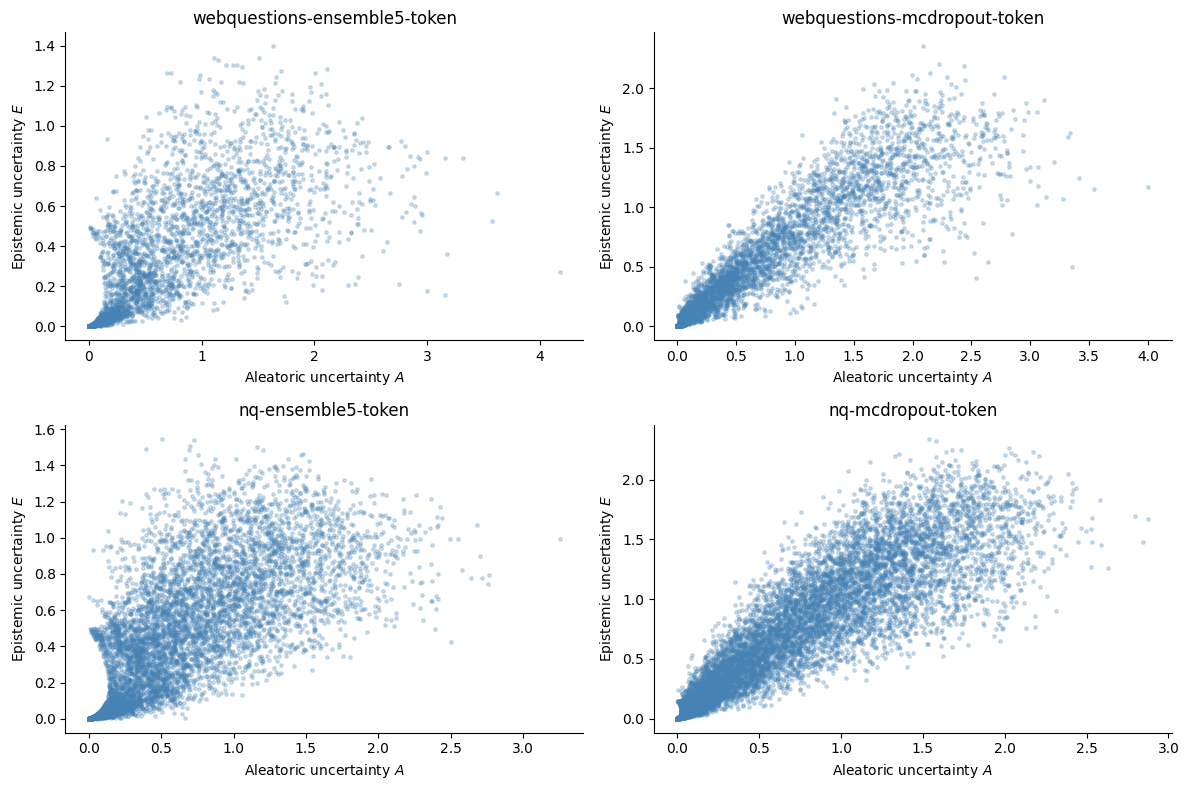

In [ ]:
datasets = ("webquestions", "nq")
methods = ("ensemble5", "mcdropout")
level_infixes = ("token",)

combinations = list(product(datasets, methods, level_infixes))
n_plots = len(combinations)

cols = 2                # for aesthetics
rows = math.ceil(n_plots / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = axes.flatten()  # Flatten in case of single row/col

for idx, (dataset, method, level_infix) in enumerate(combinations):
    df = load_results(dataset, method, "hard", "1.0", level_infix)
    au, eu = read_uncertainties(df, level_infix)

    ax = axes[idx]
    ax.scatter(au, eu, alpha=0.25, s=6, color="steelblue", rasterized=True)
    ax.set_title(f"{dataset}-{method}-{level_infix}")
    ax.set_xlabel(r"Aleatoric uncertainty $A$")
    ax.set_ylabel(r"Epistemic uncertainty $E$")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# 2. Memorization-based partitions

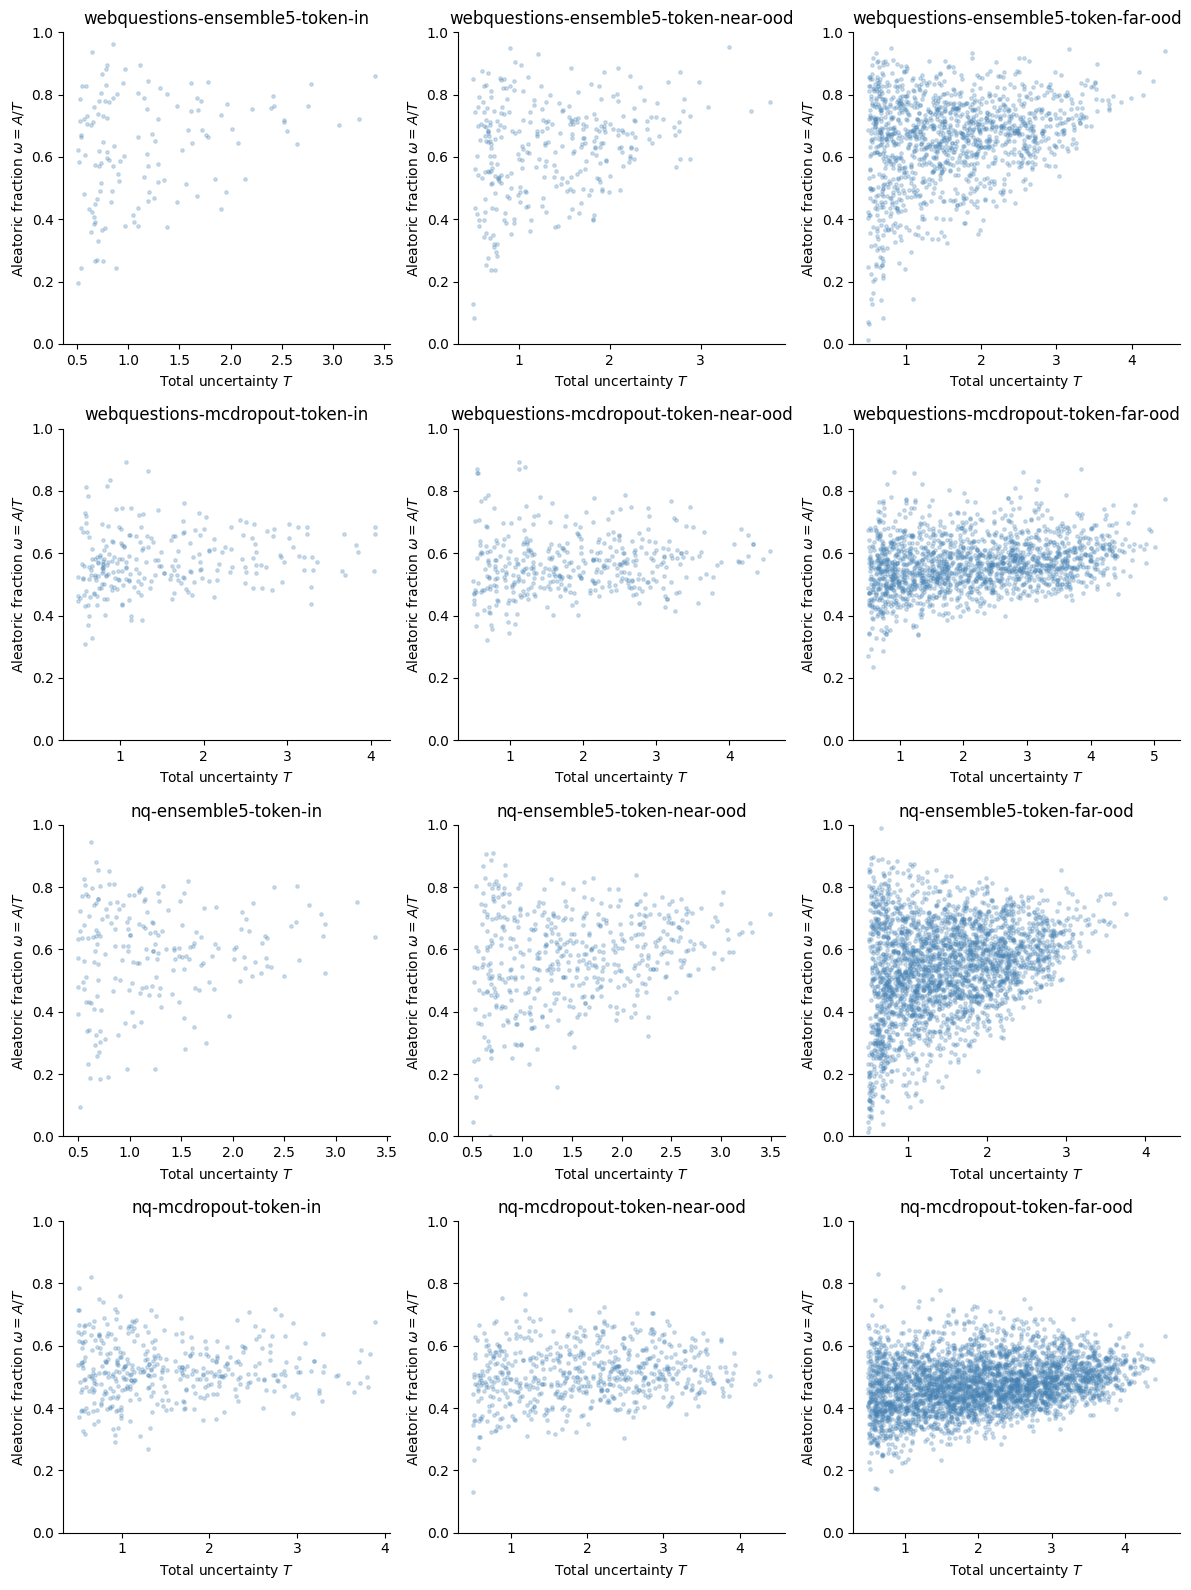

In [ ]:
datasets = ("webquestions", "nq")
methods = ("ensemble5", "mcdropout")
level_infixes = ("token",) #("token", "sampling")
subsets = ("in", "near-ood", "far-ood")
eps = 0.5

combinations = list(product(datasets, methods, level_infixes, subsets))

n_plots = len(combinations)

cols = len(subsets)
rows = math.ceil(n_plots / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = axes.flatten()  # Flatten in case of single row/col

for idx, (dataset, method, level_infix, subset) in enumerate(combinations):
    df = load_results(dataset, method, "hard", "1.0", level_infix)
    mask = df["labels"] == subset
    subset_df = df[mask]

    au, eu = read_uncertainties(df[mask], level_infix)

    total = au + eu
    omega = au / (total + 1e-8)
    mask = total > eps

    ax = axes[idx]
    ax.scatter(total[mask], omega[mask], alpha=0.25, s=6, color="steelblue", rasterized=True)
    ax.set_title(f"{dataset}-{method}-{level_infix}-{subset}")
    ax.set_xlabel(r"Total uncertainty $T$")
    ax.set_ylabel(r"Aleatoric fraction $\omega = A/T$")
    ax.set_ylim(0, 1)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# 3. Subset training

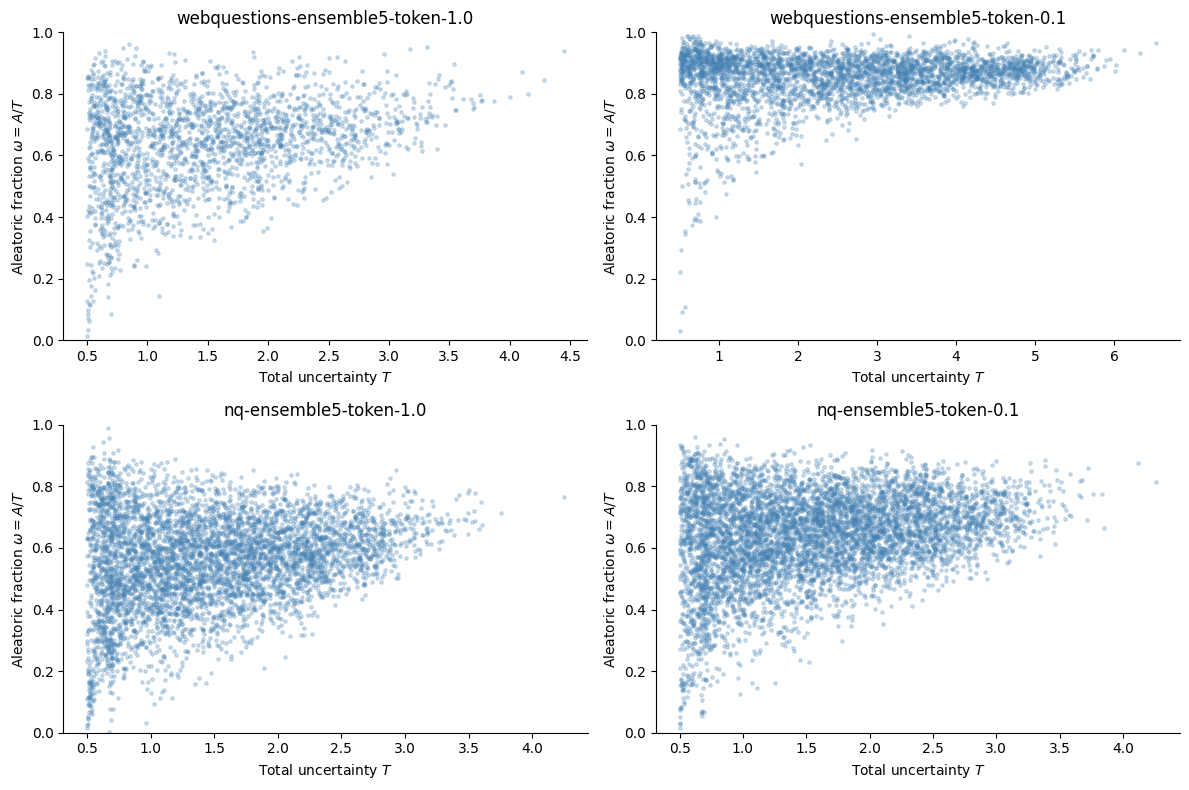

In [89]:
datasets = ("webquestions", "nq")
methods = ("ensemble5",)
fractions = ("1.0", "0.1")
level_infixes = ("token",) #("token", "sampling")
eps = 0.5

combinations = list(product(datasets, methods, fractions, level_infixes))

n_plots = len(combinations)

cols = len(fractions)
rows = math.ceil(n_plots / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = axes.flatten()  # Flatten in case of single row/col

for idx, (dataset, method, fraction, level_infix) in enumerate(combinations):
    df = load_results(dataset, method, "hard", fraction, level_infix)
    au, eu = read_uncertainties(df, level_infix)

    total = au + eu
    omega = au / (total + 1e-8)
    mask = total > eps

    ax = axes[idx]
    ax.scatter(total[mask], omega[mask], alpha=0.25, s=6, color="steelblue", rasterized=True)
    ax.set_title(f"{dataset}-{method}-{level_infix}-{fraction}")
    ax.set_xlabel(r"Total uncertainty $T$")
    ax.set_ylabel(r"Aleatoric fraction $\omega = A/T$")
    ax.set_ylim(0, 1)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# 4. Soft labels

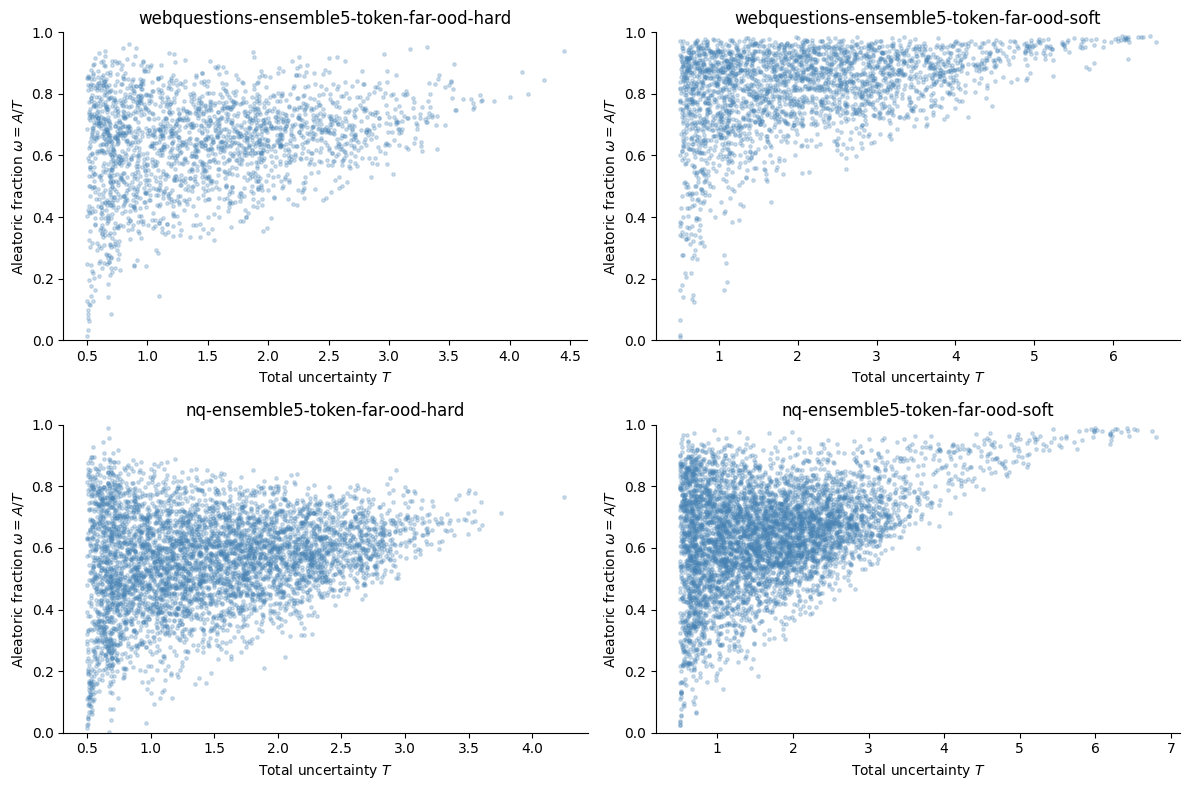

In [ ]:
datasets = ("webquestions", "nq")
methods = ("ensemble5",)
hard_infixes = ("hard", "soft")
level_infixes = ("token",) #("token", "sampling")
eps = 0.5

combinations = list(product(datasets, methods, hard_infixes, level_infixes))

n_plots = len(combinations)

cols = len(hard_infixes)
rows = math.ceil(n_plots / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = axes.flatten()  # Flatten in case of single row/col

for idx, (dataset, method, hard_infix, level_infix) in enumerate(combinations):
    df = load_results(dataset, method, hard_infix, "1.0", level_infix)
    au, eu = read_uncertainties(df, level_infix)

    total = au + eu
    omega = au / (total + 1e-8)
    mask = total > eps

    ax = axes[idx]
    ax.scatter(total[mask], omega[mask], alpha=0.25, s=6, color="steelblue", rasterized=True)
    ax.set_title(f"{dataset}-{method}-{level_infix}-{subset}-{hard_infix}")
    ax.set_xlabel(r"Total uncertainty $T$")
    ax.set_ylabel(r"Aleatoric fraction $\omega = A/T$")
    ax.set_ylim(0, 1)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()